# EP2  Machine Learning: Spotify Tracks

## 2. Modelizacion supervisada y no supervisada

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

ROOT = Path.cwd().resolve()
if not (ROOT / "Data").exists(): ROOT = ROOT.parent.parent
SRC = ROOT / "src"
if str(SRC) not in sys.path: sys.path.insert(0, str(SRC))
from preprocess import load_processed_data, build_preprocessor
from train import build_models
from metrica import regression_metrics, metrics_dataframe
from grafico import save_metrics_plot, save_scatter

RANDOM_STATE = 42
print("Proyecto:", ROOT)

Proyecto: C:\Users\Roma\Documents\proyectos dudoc\Spotify_ML_GitHub


## 1. Carga de Train/Test

In [2]:
train_path = ROOT / "Data/Processed/Train/train.csv"
test_path = ROOT / "Data/Processed/Test/test.csv"
train_df, test_df = load_processed_data(train_path, test_path)
X_train = train_df.drop(columns=["popularity"])
y_train = train_df["popularity"]
X_test = test_df.drop(columns=["popularity"])
y_test = test_df["popularity"]
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (71792, 15) Test: (17949, 15)


## 2. Modelamiento supervisado

In [3]:
categorical_features = ["track_genre"]
numeric_features = [c for c in X_train.columns if c not in categorical_features]
preprocessor = build_preprocessor(numeric_features, categorical_features)
models = build_models(preprocessor, RANDOM_STATE)
print("Modelos configurados:", list(models))

Modelos configurados: ['Regresion Lineal', 'Random Forest']


### 2.1 Entrenamiento y evaluacion

In [4]:
trained = {}
rows = []
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    trained[name] = (model, pred)
    m = regression_metrics(y_test, pred)
    rows.append({"Modelo": name, **m})
    print(name, m)

results = metrics_dataframe(rows)
display(results)
results.to_csv(ROOT / "output/Modelos/metricas_modelos.csv", index=False)
save_metrics_plot(results, ROOT / "output/Graficos/comparacion_modelos.png")

Regresion Lineal {'MAE': 17.048646298981105, 'RMSE': np.float64(20.36561933632206), 'R2': 0.0070200710220225115}
Random Forest {'MAE': 14.52776903503161, 'RMSE': np.float64(18.37081798120158), 'R2': 0.19201701581221853}


,Modelo,MAE,RMSE,R2
0,Regresion Lineal,17.048646,20.365619,0.007020
1,Random Forest,14.527769,18.370818,0.192017


WindowsPath('C:/Users/Roma/Documents/proyectos dudoc/Spotify_ML_GitHub/output/Graficos/comparacion_modelos.png')

### 2.2 Predicciones vs valores reales

In [5]:
rf_model, pred_rf = trained["Random Forest"]
path = save_scatter(y_test, pred_rf, "Random Forest: valores reales vs predicciones", "Real", "Prediccion", ROOT / "output/Graficos/predicciones_random_forest.png")
print(path)

C:\Users\Roma\Documents\proyectos dudoc\Spotify_ML_GitHub\output\Graficos\predicciones_random_forest.png


## 3. Aprendizaje no supervisado  K-Means

In [6]:
cluster_features = ["duration_ms", "explicit", "danceability", "energy", "loudness", "speechiness", "acousticness", "instrumentalness", "liveness", "valence", "tempo"]
# Para el analisis no supervisado se utiliza el conjunto completo procesado.
full_df = pd.concat([train_df, test_df], ignore_index=True)
cluster_data = full_df[cluster_features].copy()
cluster_data["explicit"] = cluster_data["explicit"].astype(int)
cluster_data = cluster_data.fillna(cluster_data.median())
scaler = StandardScaler()
X_cluster = scaler.fit_transform(cluster_data)
print("Matriz utilizada para clustering:", X_cluster.shape)

Matriz utilizada para clustering: (89741, 11)


### 3.1 Metodo del codo

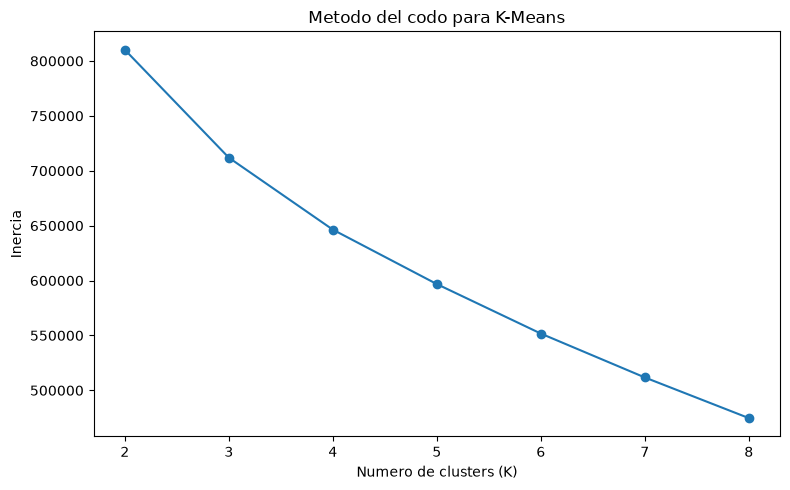

C:\Users\Roma\Documents\proyectos dudoc\Spotify_ML_GitHub\output\Graficos\metodo_codo.png


In [7]:
inertias = []
k_values = range(2, 9)
for k in k_values:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_cluster)
    inertias.append(km.inertia_)
fig, ax = plt.subplots(figsize=(8,5))
ax.plot(list(k_values), inertias, marker="o")
ax.set_title("Metodo del codo para K-Means")
ax.set_xlabel("Numero de clusters (K)")
ax.set_ylabel("Inercia")
ax.set_xticks(list(k_values))
fig.tight_layout()
path = ROOT / "output/Graficos/metodo_codo.png"
fig.savefig(path, dpi=150, bbox_inches="tight")
plt.show(); plt.close(fig)
print(path)

### 3.2 Aplicacion de K-Means

In [8]:
K = 5
kmeans = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans.fit_predict(X_cluster)
df_cluster = full_df.copy()
df_cluster["cluster"] = cluster_labels
print("Clusters creados:", K)
display(df_cluster["cluster"].value_counts().sort_index().to_frame("cantidad"))

Clusters creados: 5


,cantidad
cluster,
0,7119
1,30797
2,24036
3,19782
4,8007


### 3.3 Perfil de clusters

In [9]:
cluster_profile = df_cluster.groupby("cluster")[cluster_features + ["popularity"]].mean().round(3)
display(cluster_profile)
cluster_profile.to_csv(ROOT / "output/Modelos/perfil_clusters.csv")

,duration_ms,explicit,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,popularity
cluster,,,,,,,,,,,,
0,222570.000,0.002,0.349,0.193,-20.880,0.053,0.830,0.783,0.173,0.177,102.771,28.625
1,214031.588,0.000,0.674,0.743,-6.414,0.083,0.208,0.054,0.209,0.704,122.015,33.824
2,271900.565,0.000,0.484,0.803,-6.348,0.079,0.071,0.279,0.251,0.306,135.087,32.747
3,213259.229,0.000,0.534,0.385,-10.577,0.056,0.681,0.062,0.187,0.409,113.666,33.141
4,203985.598,0.959,0.629,0.718,-6.834,0.237,0.248,0.052,0.262,0.467,120.996,36.355


### 3.4 Generos predominantes por cluster

In [10]:
genre_cluster = pd.crosstab(df_cluster["cluster"], full_df["track_genre"], normalize="index") * 100
for cluster in genre_cluster.index:
    print(f"\nCluster {cluster}  generos predominantes:")
    display(genre_cluster.loc[cluster].sort_values(ascending=False).head(5).round(2).to_frame("porcentaje"))


Cluster 0  generos predominantes:


,porcentaje
track_genre,
sleep,11.98
new-age,10.91
ambient,9.62
classical,8.78
iranian,6.45



Cluster 1  generos predominantes:


,porcentaje
track_genre,
forro,2.78
salsa,2.77
kids,2.63
afrobeat,2.30
disco,2.27



Cluster 2  generos predominantes:


,porcentaje
track_genre,
black-metal,3.44
grindcore,3.39
drum-and-bass,3.35
heavy-metal,3.25
happy,2.97



Cluster 3  generos predominantes:


,porcentaje
track_genre,
tango,4.48
honky-tonk,4.04
cantopop,3.71
romance,3.66
acoustic,3.18



Cluster 4  generos predominantes:


,porcentaje
track_genre,
comedy,11.38
emo,5.58
dancehall,3.70
hardcore,3.63
j-dance,3.62


### 3.5 Visualizacion con PCA

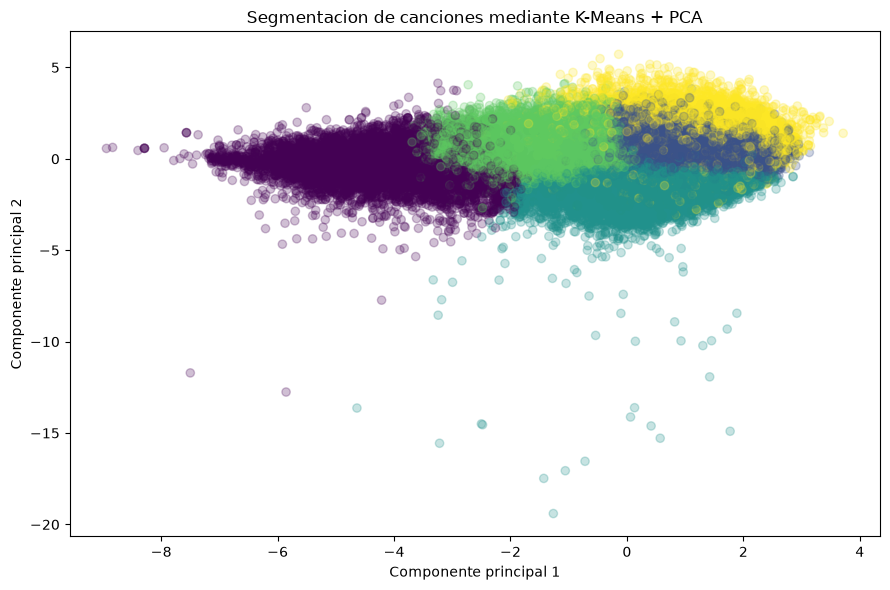

Varianza explicada PC1: 0.2657
Varianza explicada PC2: 0.1401


In [11]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_cluster)
fig, ax = plt.subplots(figsize=(9,6))
ax.scatter(X_pca[:,0], X_pca[:,1], c=cluster_labels, alpha=0.25)
ax.set_title("Segmentacion de canciones mediante K-Means + PCA")
ax.set_xlabel("Componente principal 1")
ax.set_ylabel("Componente principal 2")
fig.tight_layout()
path = ROOT / "output/Graficos/clusters_pca.png"
fig.savefig(path, dpi=150, bbox_inches="tight")
plt.show(); plt.close(fig)
print("Varianza explicada PC1:", round(pca.explained_variance_ratio_[0],4))
print("Varianza explicada PC2:", round(pca.explained_variance_ratio_[1],4))

## 4. Cierre

Los resultados numericos y conclusiones deben completarse despues de ejecutar todo el notebook con el dataset.